## Green-space accessibility in Marseille

In [1]:
# Imports and file locations
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Data files are stored in the project's data folder
DATA_DIR = Path("data")

LIDAR_FILE = DATA_DIR / "lidar_4326_Marseille.csv"
QUARTIERS_FILE = DATA_DIR / "quartiers-marseille.geojson"

In [3]:
# Folder for generated analysis results
RESULTS_DIR = Path("marseille_lidar_analysis_results")
RESULTS_DIR.mkdir(exist_ok=True)

In [4]:
WGS84 = "EPSG:4326"
METRIC_CRS = "EPSG:2154"  # Lambert-93, metres; suitable for mainland France
RANDOM_SEED = 42

##### Load and inspect the data

In [5]:
lidar_raw = pd.read_csv(LIDAR_FILE, sep=",")
quartiers = gpd.read_file(QUARTIERS_FILE)

In [6]:
lidar_raw.head(3)

,ID,Height_m,Longitude,Latitude
0,967,2.72,5.358388,43.374717
1,966,3.79,5.356419,43.374767
2,977,2.40,5.358954,43.374673


In [7]:
quartiers[["code_qua", "nom", "NOM_CO", "geometry"]].head(3)

,code_qua,nom,NOM_CO,geometry
0,1320101,Belsunce,Marseille 1er Arrondissement,"POLYGON ((5.37202 43.29938, 5.37208 43.29936, ..."
1,1320102,Le Chapitre,Marseille 1er Arrondissement,"POLYGON ((5.38067 43.30039, 5.38068 43.30057, ..."
2,1320103,Noailles,Marseille 1er Arrondissement,"POLYGON ((5.38177 43.29518, 5.38195 43.29461, ..."


In [8]:
print(f"Lidar records: {len(lidar_raw):,}")
print(f"Quartier polygons: {len(quartiers):,}")
print(f"Quartier CRS: {quartiers.crs}")

Lidar records: 766,641
Quartier polygons: 111
Quartier CRS: EPSG:4326


In [9]:
required_columns = {"ID", "Height_m", "Longitude", "Latitude"}
missing_columns = required_columns.difference(lidar_raw.columns)
if missing_columns:
    raise ValueError(f"The Trees CSV is missing: {sorted(missing_columns)}")
if quartiers.crs is None:
    raise ValueError("The quartier GeoJSON has no CRS. Set it explicitly before analysis.")

<Axes: >

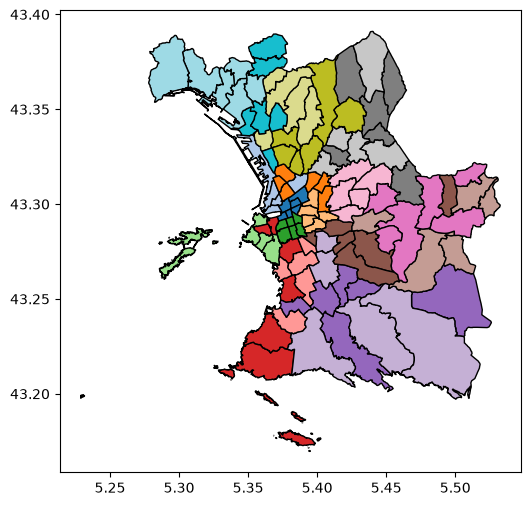

In [10]:
quartiers.plot(figsize=(6,6), edgecolor="black", cmap = 'tab20')

##### Validate LiDAR heights and create point geometries

In [11]:
numeric_fields = ["Height_m", "Longitude", "Latitude"]
for field in numeric_fields:
    lidar_raw[field] = pd.to_numeric(lidar_raw[field], errors="coerce")

In [12]:
valid_rows = (
    lidar_raw["Longitude"].between(-180, 180)
    & lidar_raw["Latitude"].between(-90, 90)
    & lidar_raw["Height_m"].notna()
    & lidar_raw["Height_m"].ge(0)
)
lidar_clean = lidar_raw.loc[valid_rows, ["ID", "Height_m", "Longitude", "Latitude"]].copy()
print(f"Excluded invalid records: {(~valid_rows).sum():,}")
print(f"Valid records retained: {len(lidar_clean):,}")

Excluded invalid records: 0
Valid records retained: 766,641


In [13]:
lidar_points = gpd.GeoDataFrame(
    lidar_clean,
    geometry=gpd.points_from_xy(lidar_clean["Longitude"], lidar_clean["Latitude"]),
    crs=WGS84,
)
quartiers_wgs84 = quartiers.to_crs(WGS84)

In [14]:
quartiers.head(1), quartiers_wgs84.head(1)

(  prefixe code_qua  num_qua       nom  DEPCO                        NOM_CO  \
 0     801  1320101        1  Belsunce  13201  Marseille 1er Arrondissement   
 
                                             geometry  
 0  POLYGON ((5.37202 43.29938, 5.37208 43.29936, ...  ,
   prefixe code_qua  num_qua       nom  DEPCO                        NOM_CO  \
 0     801  1320101        1  Belsunce  13201  Marseille 1er Arrondissement   
 
                                             geometry  
 0  POLYGON ((5.37202 43.29938, 5.37208 43.29936, ...  )

##### Spatial join: assign LiDAR observations to quartiers

The spatial join links each point to the quartier polygon that contains it. Unmatched points remain visible for quality control, they may be outside the quartier layer or lie on a boundary.

In [15]:
quartier_fields = ["code_qua", "nom", "NOM_CO", "geometry"]
lidar_with_quartier = gpd.sjoin(
    lidar_points,
    quartiers_wgs84[quartier_fields],
    how="left",
    predicate="within",
)

In [16]:
matched = lidar_with_quartier.dropna(subset=["code_qua"]).copy()
unmatched_count = len(lidar_with_quartier) - len(matched)
print(f"Points assigned to a quartier: {len(matched):,}")
print(f"Points not assigned to a quartier: {unmatched_count:,}")
print(f"Quartiers represented by at least one point: {matched['code_qua'].nunique():,}")

Points assigned to a quartier: 761,990
Points not assigned to a quartier: 4,651
Quartiers represented by at least one point: 110


##### Create neighborhood LiDAR indicators

Each quartier receives a count of valid points and a set of height statistics. Median height is especially useful because it is less affected by extreme values than the mean. The 10th and 90th percentiles show the lower and upper portions of the height distribution.

`points_per_sq_km` measures sampling density only. It should not be interpreted as population density, asset density, or tree density.

In [17]:
quartiers_metric = quartiers.to_crs(METRIC_CRS).copy()
quartiers_metric["area_sq_km"] = quartiers_metric.geometry.area / 1_000_000

In [22]:
grouped = matched.groupby("code_qua")["Height_m"]
height_statistics = grouped.agg(
    lidar_point_count="count",
    mean_height_m="mean",
    median_height_m="median",
    min_height_m="min",
    max_height_m="max",
    std_height_m="std",
)

In [23]:
height_percentiles = grouped.quantile([0.10, 0.90]).unstack()
height_percentiles.columns = ["p10_height_m", "p90_height_m"]
height_statistics = height_statistics.join(height_percentiles)

In [24]:
quartier_stats = quartiers_metric.merge(
    height_statistics, how="left", left_on="code_qua", right_index=True
)

In [25]:
quartier_stats["lidar_point_count"] = quartier_stats["lidar_point_count"].fillna(0).astype(int)
quartier_stats["points_per_sq_km"] = np.where(
    quartier_stats["area_sq_km"] > 0,
    quartier_stats["lidar_point_count"] / quartier_stats["area_sq_km"],
    np.nan,
)

In [40]:
print("Citywide valid LiDAR-height summary (metres):")
display(trees_clean["Height_m"].describe(percentiles=[0.1, 0.5, 0.9]).to_frame().T)


Citywide valid LiDAR-height summary (metres):


,count,mean,std,min,10%,50%,90%,max
Height_m,766641.0,6.898712,4.418399,1.5,2.33,5.75,13.01,101.94


##### Review and export neighborhood results

The GeoJSON includes the same statistics with geometry for use in QGIS or other GIS software. The notebook exports only the summarized polygons—not a very large point GeoJSON.

In [26]:
summary_columns = [
    "code_qua", "nom", "NOM_CO", "area_sq_km", "lidar_point_count",
    "points_per_sq_km", "mean_height_m", "median_height_m",
    "p10_height_m", "p90_height_m", "min_height_m", "max_height_m", "std_height_m",
]
summary = quartier_stats[summary_columns].sort_values("median_height_m", ascending=False)

In [27]:
print("Quartiers with the highest median LiDAR height:")
display(summary.head(3))

Quartiers with the highest median LiDAR height:


,code_qua,nom,NOM_CO,area_sq_km,lidar_point_count,points_per_sq_km,mean_height_m,median_height_m,p10_height_m,p90_height_m,min_height_m,max_height_m,std_height_m
2,1320103,Noailles,Marseille 1er Arrondissement,0.149433,68,455.053264,12.934412,13.51,5.537,16.866,4.81,21.85,4.052569
26,1320605,Préfecture,Marseille 6e Arrondissement,0.209987,203,966.726336,11.950542,12.55,4.920,18.240,2.03,24.95,5.101206
1,1320102,Le Chapitre,Marseille 1er Arrondissement,0.238077,341,1432.306924,12.475337,12.28,6.850,17.410,1.58,37.13,4.856894


In [28]:
print("Quartiers with no assigned valid LiDAR observations:")
display(summary.loc[summary["lidar_point_count"].eq(0), ["code_qua", "nom", "NOM_CO", "area_sq_km"]])

Quartiers with no assigned valid LiDAR observations:


,code_qua,nom,NOM_CO,area_sq_km
30,1320703,Les Îles,Marseille 7e Arrondissement,1.894777


In [29]:
summary.to_csv(RESULTS_DIR / "marseille_quartier_lidar_height_statistics.csv", index=False)
quartier_stats.to_crs(WGS84).to_file(
    RESULTS_DIR / "marseille_quartier_lidar_height_statistics.geojson",
    driver="GeoJSON",
)

##### Visualize height and sampling patterns

In [30]:
sample_size = min(50_000, len(lidar_points))
map_points = lidar_points.sample(n=sample_size, random_state=RANDOM_SEED).to_crs(METRIC_CRS)

(np.float64(880035.2351682803),
 np.float64(906804.0649530335),
 np.float64(6231762.550036102),
 np.float64(6258951.249541028))

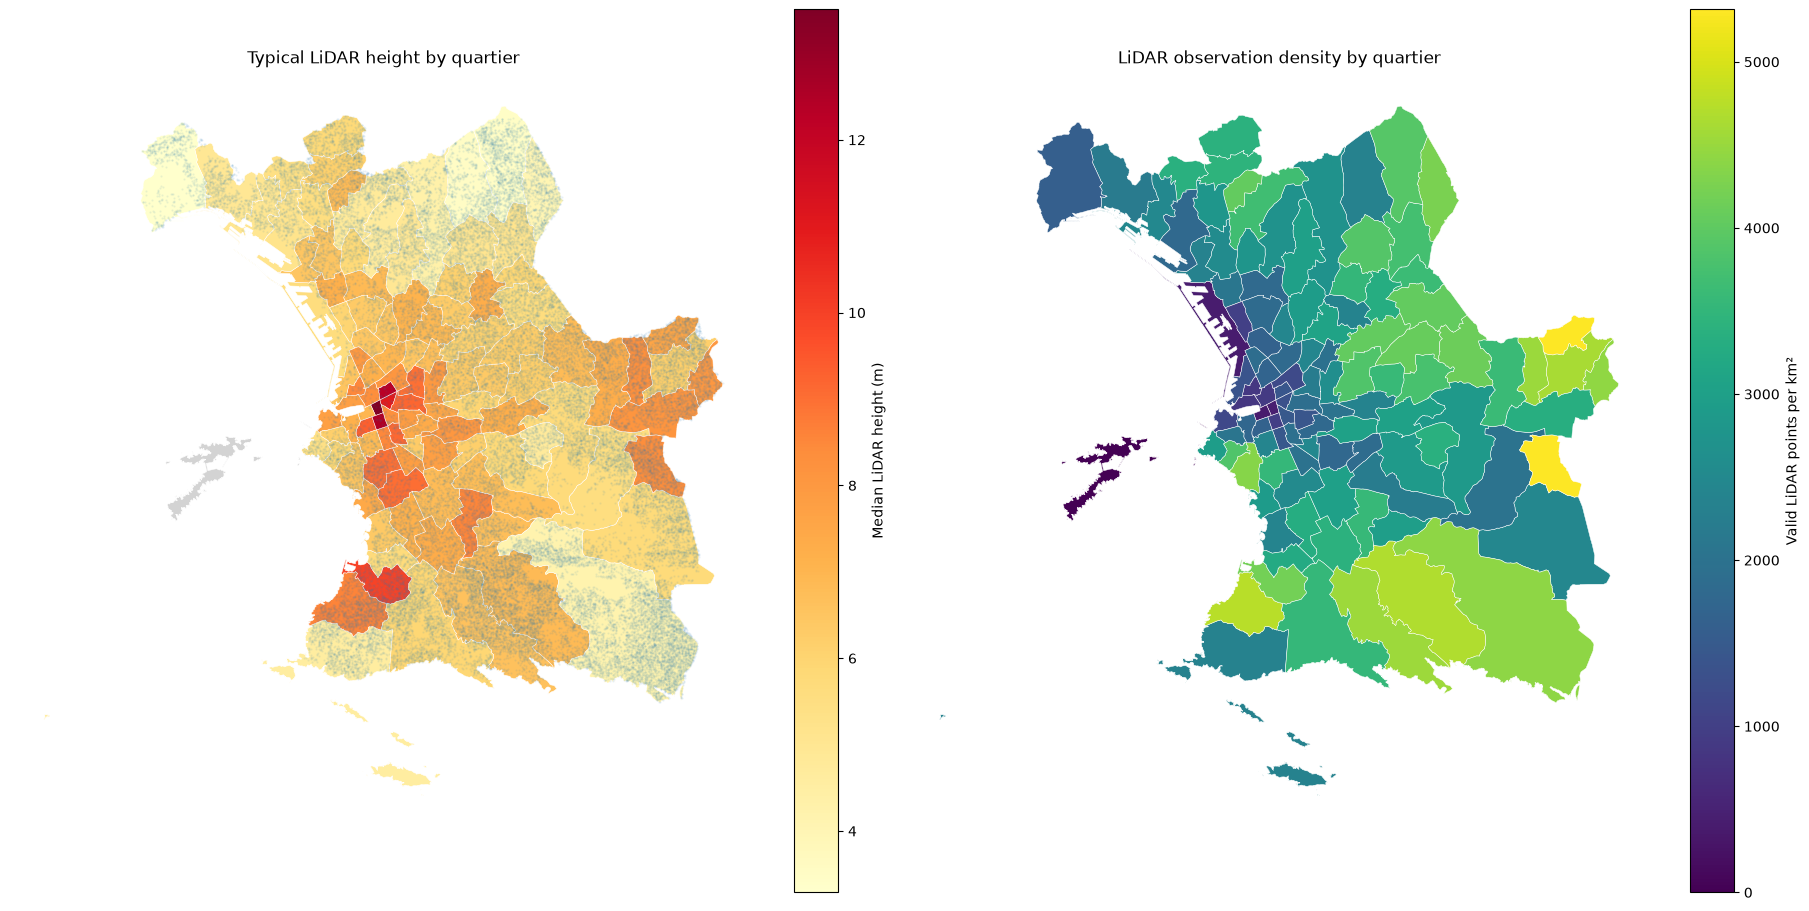

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

quartier_stats.plot(
    ax=axes[0], column="median_height_m", cmap="YlOrRd",
    edgecolor="white", linewidth=0.35, legend=True,
    legend_kwds={"label": "Median LiDAR height (m)"},
    missing_kwds={"color": "lightgrey", "label": "No observations"},
)

map_points.plot(ax=axes[0], color="#2c7fb8", markersize=0.25, alpha=0.10)
axes[0].set_title("Typical LiDAR height by quartier")
axes[0].axis("off")

quartier_stats.plot(
    ax=axes[1], column="points_per_sq_km", cmap="viridis",
    edgecolor="white", linewidth=0.35, legend=True,
    legend_kwds={"label": "Valid LiDAR points per km²"},
    missing_kwds={"color": "lightgrey", "label": "No observations"},
)
axes[1].set_title("LiDAR observation density by quartier")
axes[1].axis("off")

In [33]:
# Derive concise insights from the quartier-level indicators
valid_stats = quartier_stats.dropna(subset=["median_height_m"]).copy()

highest_median = valid_stats.nlargest(5, "median_height_m")[
    ["nom", "NOM_CO", "median_height_m", "lidar_point_count"]
]
lowest_median = valid_stats.nsmallest(5, "median_height_m")[
    ["nom", "NOM_CO", "median_height_m", "lidar_point_count"]
]
densest = quartier_stats.nlargest(5, "points_per_sq_km")[
    ["nom", "NOM_CO", "points_per_sq_km"]
]

correlation = valid_stats["median_height_m"].corr(
    valid_stats["points_per_sq_km"]
)

print("Quartiers with the highest median LiDAR heights:")
display(highest_median)

print("Quartiers with the lowest median LiDAR heights:")
display(lowest_median)

print("Quartiers with the highest LiDAR sampling density:")
display(densest)

print(f"Correlation between median height and sampling density: {correlation:.2f}")
print(
    f"Quartiers without valid observations: "
    f"{(quartier_stats['lidar_point_count'] == 0).sum()}"
)

Quartiers with the highest median LiDAR heights:


,nom,NOM_CO,median_height_m,lidar_point_count
2,Noailles,Marseille 1er Arrondissement,13.51,68
26,Préfecture,Marseille 6e Arrondissement,12.55,203
1,Le Chapitre,Marseille 1er Arrondissement,12.28,341
5,Thiers,Marseille 1er Arrondissement,10.92,259
40,La Pointe Rouge,Marseille 8e Arrondissement,9.95,8589


Quartiers with the lowest median LiDAR heights:


,nom,NOM_CO,median_height_m,lidar_point_count
108,Les Riaux,Marseille 16e Arrondissement,3.29,9650
84,Palama,Marseille 13e Arrondissement,3.47,19498
82,Les Mourets,Marseille 13e Arrondissement,3.51,10059
81,Les Médecins,Marseille 13e Arrondissement,4.04,12788
53,Vaufrèges,Marseille 9e Arrondissement,4.19,87455


Quartiers with the highest LiDAR sampling density:


,nom,NOM_CO,points_per_sq_km
64,La Millière,Marseille 11e Arrondissement,5316.089702
68,La Treille,Marseille 11e Arrondissement,5308.240796
37,Montredon,Marseille 8e Arrondissement,4749.214463
50,Le Redon,Marseille 9e Arrondissement,4676.493923
62,Les Camoins,Marseille 11e Arrondissement,4613.379231


Correlation between median height and sampling density: -0.28
Quartiers without valid observations: 1


In [34]:
fig.savefig(RESULTS_DIR / "marseille_lidar_height_by_quartier.png", dpi=200, bbox_inches="tight")
plt.show()

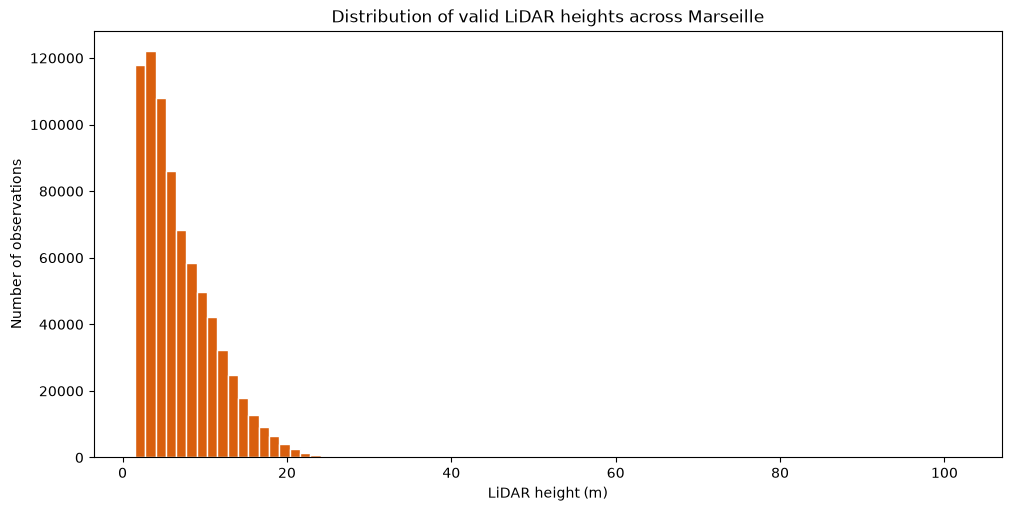

In [35]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.hist(lidar_clean["Height_m"], bins=80, color="#d95f0e", edgecolor="white")
ax.set_title("Distribution of valid LiDAR heights across Marseille")
ax.set_xlabel("LiDAR height (m)")
ax.set_ylabel("Number of observations")
fig.savefig(RESULTS_DIR / "marseille_lidar_height_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

#### Insights, impact, and limitations

This project turns a large point cloud of official LiDAR heights into comparable quartier-level indicators. It can help reveal where typical measured height is relatively high or low, where the height distribution is highly variable, and where observation coverage deserves quality review. These outputs are useful for urban-form screening, LiDAR product validation, and targeting more detailed spatial analysis.

The results do not identify the objects represented by the heights. Do not call a high-height quartier greener, more built-up, or more densely populated without adding verified land-cover, building, tree, population, or infrastructure layers. Differences can also reflect the source product's resolution, acquisition date, and processing approach.

Useful next steps are to add an official building-footprint or land-cover layer, vegetation classification, digital terrain/surface models, and population data. Those additions would support separate analyses of buildings, vegetation, urban form, and population exposure.